this notebook contains:

- code to get the data from the fish freshness mobile app testing, clean the data, analyzing the results and providing confusion matrices and classification metrics.
- code to download that app testing data from s3 bucket
- code to download data based on the reason like softness, cut, smell etc.

In [1]:
import psycopg2
import pandas as pd
import os
import boto3
from tqdm import tqdm

conn = psycopg2.connect(
    dbname="postgres",
    user="mobileapi2",
    password="mobileapi2",
    # host="mobileapi2.cegw5dvtv2xs.ap-south-1.rds.amazonaws.com",
    host="mobileapi2.c5gmcqq8k94k.ap-south-1.rds.amazonaws.com",
    port="5432"
)
cur = conn.cursor()
# cur.execute("SELECT * FROM fishinfo")  #Download whole table
cur.execute('SELECT * FROM "Feedback"') # Download rows after specific id (TO DOWNLOAD ONLY NEW IMAGES)
rows = cur.fetchall()
column_names = [desc[0] for desc in cur.description]
df = pd.DataFrame(rows, columns=column_names)
cur.close()
conn.close()
df.head()

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason
0,1,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,B,G,G,False,2023-11-23 04:11:45.771266+00:00,demo,None
1,2,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:12:02.582968+00:00,demo,None
2,3,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:12:24.689801+00:00,demo,None
3,4,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:13:19.877843+00:00,demo,None
4,5,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,B,False,2023-11-23 04:13:46.147758+00:00,demo,None


In [2]:
df.tail()

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason
8373,8421,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,G,None,Correct,2025-01-28 05:42:34.128798+00:00,demo,"[None, None]"
8374,8422,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,G,None,Correct,2025-01-28 05:42:40.334695+00:00,demo,"[None, None]"
8375,8423,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,G,None,Correct,2025-01-28 05:42:47.820412+00:00,demo,"[None, None]"
8376,8424,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,B,None,False,2025-01-28 05:42:54.694209+00:00,demo,"[None, 'Softness']"
8377,8425,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,G,None,Correct,2025-02-03 17:41:12.320724+00:00,test,"[None, None]"


In [3]:
# df = df[df['user_name']=='demo'].reset_index(drop=True)
df['Date'] = df['input_image_url'].apply(lambda x: x.split('/')[-2])
df['Species'] = df['input_image_url'].apply(lambda x: x.split('/')[-1].split('_')[-2])

In [4]:
from urllib.parse import urlparse

def get_filename(url):
    # Parse the URL to extract bucket name and object key
    parsed_url = urlparse(url)
    object_key = parsed_url.path[1:]  # Remove the leading '/'
    filename = os.path.basename(object_key)
    return filename

df['filename'] = df['input_image_url'].apply(get_filename)

In [5]:
df.user_name.unique()

array(['demo', 'demo2', 'test', 'foumql', 'srishti', 'kartik',
       'kartik_test', None], dtype=object)

In [6]:
df['filename_id'] = df['filename'].apply(lambda x: x.split('_')[2])
df.head()

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason,Date,Species,filename,filename_id
0,1,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,B,G,G,False,2023-11-23 04:11:45.771266+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:41:35_(2184)_sardine_input.jpeg,(2184)
1,2,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:12:02.582968+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:41:59_(2185)_sardine_input.jpeg,(2185)
2,3,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:12:24.689801+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:42:22_(2186)_sardine_input.jpeg,(2186)
3,4,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:13:19.877843+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:43:17_(2188)_sardine_input.jpeg,(2188)
4,5,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,B,False,2023-11-23 04:13:46.147758+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:43:38_(2189)_sardine_input.jpeg,(2189)


In [7]:
df.shape

(8378, 17)

In [8]:
df = df[df['user_name']!='test']

In [9]:
df.shape

(7970, 17)

In [10]:
# drop rows with null values in the 'user_name' column
df = df.dropna(subset=['user_name'])

In [11]:
df.user_name.unique()

array(['demo', 'demo2', 'foumql', 'srishti', 'kartik', 'kartik_test'],
      dtype=object)

In [12]:
df.shape

(7955, 17)

In [13]:
repeat_file_ids = {}
for file_id in set(df['filename_id']):
    if df['filename_id'].value_counts()[file_id]>1:
        date = df[df['filename_id'] == file_id]['Date'].unique()[0]
        repeat_file_ids[file_id] = (df['filename_id'].value_counts()[file_id], date)

In [14]:
repeat_file_ids

{}

In [15]:
df[df['filename_id'].isin(repeat_file_ids.keys())]

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason,Date,Species,filename,filename_id


In [16]:
df = df.drop_duplicates(subset='filename_id', keep='first')
df.shape

(7955, 17)

In [17]:
df.dtypes

serial_number                      int64
input_image_url                   object
output_image_url                  object
fish1_actual                      object
fish2_actual                      object
fish3_actual                      object
fish1_pred                        object
fish2_pred                        object
fish3_pred                        object
result                            object
timestamp            datetime64[ns, UTC]
user_name                         object
prediction_reason                 object
Date                              object
Species                           object
filename                          object
filename_id                       object
dtype: object

In [18]:
df

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason,Date,Species,filename,filename_id
0,1,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,B,G,G,False,2023-11-23 04:11:45.771266+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:41:35_(2184)_sardine_input.jpeg,(2184)
1,2,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:12:02.582968+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:41:59_(2185)_sardine_input.jpeg,(2185)
2,3,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:12:24.689801+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:42:22_(2186)_sardine_input.jpeg,(2186)
3,4,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,G,Correct,2023-11-23 04:13:19.877843+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:43:17_(2188)_sardine_input.jpeg,(2188)
4,5,https://mobile-api-results.s3.ap-south-1.amazo...,https://mobile-api-results.s3.ap-south-1.amazo...,G,G,G,G,G,B,False,2023-11-23 04:13:46.147758+00:00,demo,None,2023-11-23,sardine,2023-11-23_09:43:38_(2189)_sardine_input.jpeg,(2189)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8372,8420,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,G,None,Correct,2025-01-28 05:42:27.780196+00:00,demo,"[None, None]",2025-01-28,mackerel,2025-01-28_11:12:26_(19245)_mackerel_input.jpeg,(19245)
8373,8421,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,G,None,Correct,2025-01-28 05:42:34.128798+00:00,demo,"[None, None]",2025-01-28,mackerel,2025-01-28_11:12:32_(19246)_mackerel_input.jpeg,(19246)
8374,8422,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,G,None,Correct,2025-01-28 05:42:40.334695+00:00,demo,"[None, None]",2025-01-28,mackerel,2025-01-28_11:12:39_(19247)_mackerel_input.jpeg,(19247)
8375,8423,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,G,G,None,Correct,2025-01-28 05:42:47.820412+00:00,demo,"[None, None]",2025-01-28,mackerel,2025-01-28_11:12:45_(19248)_mackerel_input.jpeg,(19248)


In [19]:
def filter_df(df, filters={}):
    """
    Filter a pandas DataFrame based on specified conditions for each column.

    Parameters:
    - df (pd.DataFrame): The DataFrame to be filtered.
    - filters (dict): A dictionary where keys are column names, and values are the conditions
                     to filter on. Values can be a single value or a list of values for each column.

    Returns:
    pd.DataFrame: A new DataFrame containing only the rows that satisfy the specified conditions.

    Example:
    >>> filters = {'column1': value1, 'column2': [value2a, value2b], 'column3': value3}
    >>> result_df = filter_df(your_dataframe, filters)
    """

    if not filters:
        return df  # If no filters provided, return the original DataFrame

    # Initialize a boolean mask to True for all rows
    mask = [True] * len(df)

    # Apply filters for each column and its corresponding values in the dictionary
    for col, vals in filters.items():
        if not isinstance(vals, list):
            vals = [vals]  # Convert single value to a list

        mask &= df[col].isin(vals)

    # Use the boolean mask to filter the DataFrame
    filtered_df = df[mask]

    return filtered_df


In [20]:
from sklearn.metrics import confusion_matrix

def conf_matrix(df, species='mackerel'):
    # Assuming df is your DataFrame
    actual_values = df[['fish1_actual', 'fish2_actual', 'fish3_actual']].values.flatten()
    predicted_values = df[['fish1_pred', 'fish2_pred', 'fish3_pred']].values.flatten()
    actual_values = actual_values[actual_values != None]
    predicted_values = predicted_values[predicted_values != None]

    # Create a confusion matrix
    conf_matrix = confusion_matrix(actual_values, predicted_values, labels=['G', 'B'])

    # Display the confusion matrix
    conf_matrix_df = pd.DataFrame(conf_matrix, index=['Actual Good', 'Actual Bad'],
                                  columns=['Predicted Good', 'Predicted Bad'])
    print('\t'*3, species, 'results', '\n'*2, conf_matrix_df)

In [6]:
from sklearn.metrics import classification_report
import numpy as np
def print_classification_report_v1(confusion_matrix):
    # Extract the values from the confusion matrix
    tp, fn, fp, tn = confusion_matrix.ravel()
    print(f"\ttp: {tp}, fn: {fn}, fp: {fp}, tn: {tn}\n")

    # Create true labels and predicted labels
    true_labels = [0] * (tp + fn) + [1] * (fp + tn)
    predicted_labels = ([0]*tp)+([1]*fn)+([0]*fp)+([1]*tn)
    
    # Generate the classification report
    report = classification_report(true_labels, predicted_labels,
                                   target_names=["Good", "Bad"],
                                   zero_division=1)

    # Print the classification report
    print(report)

In [4]:
from sklearn.metrics import classification_report
import numpy as np

def print_classification_report(confusion_matrix):
    # Extract the values from the confusion matrix
    tp, fn, fp, tn = confusion_matrix.ravel()
    print(f"\ttp: {tp}, fn: {fn}, fp: {fp}, tn: {tn}\n")

    # Create true labels and predicted labels
    true_labels = [0] * (tp + fn) + [1] * (fp + tn)
    predicted_labels = ([0]*tp)+([1]*fn)+([0]*fp)+([1]*tn)
    
    label_map = {'Bad':0, 'Good':1}
    class_labels = list(label_map.keys())

    unique_class_labels = list(set(true_labels) | set(predicted_labels))
    
    # Create a target_names list based on the unique class labels
    new_class_labels = [k for k, v in label_map.items() if v in unique_class_labels]
    
    # Convert true labels and predictions to class names
    true_class_names = [class_labels[i] for i in true_labels]
    predicted_class_names = [class_labels[i] for i in predicted_labels]
    
    # cm = confusion_matrix(true_class_names, predicted_class_names, 
    #                       labels=new_class_labels)

    # Generate the classification report
    report = classification_report(true_labels, predicted_labels, 
                                   target_names=new_class_labels,
                                   zero_division=1)

    # Print the classification report
    print(report)

In [23]:
import pandas as pd

def get_unique_values(df, column_names):
    """
    Get unique values for a list of column names in a DataFrame.

    Parameters:
    - df (pd.DataFrame): The DataFrame to extract unique values from.
    - column_names (list): A list of column names for which to find unique values.

    Returns:
    dict: A dictionary where keys are column names, and values are lists of unique values.
    """
    unique_values_dict = {}

    for col in column_names:
        unique_values_dict[col] = sorted(df[col].unique().tolist())

    return unique_values_dict

# Example usage:
column_names = ['Date', 'Species']
unique_values = get_unique_values(df, column_names)
print(unique_values)


{'Date': ['2023-11-01', '2023-11-23', '2023-11-25', '2023-11-28', '2023-11-29', '2023-11-30', '2023-12-05', '2023-12-06', '2023-12-07', '2023-12-08', '2023-12-12', '2023-12-13', '2023-12-14', '2023-12-15', '2023-12-19', '2023-12-23', '2023-12-27', '2023-12-28', '2023-12-29', '2023-12-30', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05', '2024-01-09', '2024-01-10', '2024-01-11', '2024-01-12', '2024-01-16', '2024-01-18', '2024-01-19', '2024-01-23', '2024-02-06', '2024-02-07', '2024-02-08', '2024-02-09', '2024-02-13', '2024-02-16', '2024-02-20', '2024-02-21', '2024-02-22', '2024-02-23', '2024-02-25', '2024-02-28', '2024-02-29', '2024-03-01', '2024-03-05', '2024-03-06', '2024-03-12', '2024-03-13', '2024-03-14', '2024-03-15', '2024-03-19', '2024-03-21', '2024-03-22', '2024-03-26', '2024-03-27', '2024-03-28', '2024-04-02', '2024-04-03', '2024-04-04', '2024-04-05', '2024-04-09', '2024-04-11', '2024-04-18', '2024-04-23', '2024-04-25', '2024-05-02', '2024-05-07', '2024-05-09', '2024-05-1

In [24]:
sorted(df['Date'].unique())[-1]

'2025-01-28'

In [25]:
date_range = ['2024-12-02', '2025-01-31']

all_dates = sorted(df.Date.unique())
date_list = [date for date in all_dates if date_range[0] <= date <= date_range[1]]

filters = {'Species': ['sardine'], 'Date': date_list}
result_df = filter_df(df, filters)
conf_matrix(result_df, 'sardine')

			 sardine results 

              Predicted Good  Predicted Bad
Actual Good             609            223
Actual Bad              112            363


In [26]:
# confusion_matrix = np.array([[tp, fn], [fp, tn]])  # Your input with positive class first
cm = np.array([[609, 223], [112, 363]])
print_classification_report_v1(cm)

	tp: 609, fn: 223, fp: 112, tn: 363

              precision    recall  f1-score   support

        Good       0.84      0.73      0.78       832
         Bad       0.62      0.76      0.68       475

    accuracy                           0.74      1307
   macro avg       0.73      0.75      0.73      1307
weighted avg       0.76      0.74      0.75      1307



In [54]:
k = result_df.sort_values(by='Date')[['filename', 'filename_id', 'fish1_actual', 'fish1_pred', 'fish2_actual', 'fish2_pred', 'prediction_reason', 'Species', 'Date', 'fish3_actual', 'fish3_pred']]

In [56]:
combined_counts = pd.DataFrame({
    'fish1_actual': k.groupby('Date')['fish1_actual'].value_counts(),
    'fish2_actual': k.groupby('Date')['fish2_actual'].value_counts()
}).unstack(fill_value=0)
combined_counts['actual_good'] = combined_counts['fish1_actual']['G'] + combined_counts['fish2_actual']['G']
combined_counts['actual_bad'] = combined_counts['fish1_actual']['B'] + combined_counts['fish2_actual']['B']
combined_counts[['actual_good', 'actual_bad']]

,actual_good,actual_bad
,,
Date,,
2024-12-03,4.0,58.0
2024-12-10,NaN,99.0
2024-12-17,53.0,33.0
2024-12-19,108.0,6.0
2024-12-24,64.0,26.0
2024-12-26,108.0,58.0
2025-01-02,93.0,17.0
2025-01-21,272.0,80.0


In [57]:
g = k[k['Date']=='2025-01-23']

In [58]:
g

,filename,filename_id,fish1_actual,fish1_pred,fish2_actual,fish2_pred,prediction_reason,Species,Date,fish3_actual,fish3_pred
8130,2025-01-23_10:33:54_(19003)_sardine_input.jpeg,(19003),B,B,B,B,"['Softness', 'Softness']",sardine,2025-01-23,None,None
8134,2025-01-23_10:34:28_(19007)_sardine_input.jpeg,(19007),G,G,G,G,"[None, None]",sardine,2025-01-23,None,None
8133,2025-01-23_10:34:21_(19006)_sardine_input.jpeg,(19006),G,G,G,B,"[None, 'Softness']",sardine,2025-01-23,None,None
8136,2025-01-23_10:34:45_(19009)_sardine_input.jpeg,(19009),G,B,G,B,"['Softness', 'Softness']",sardine,2025-01-23,None,None
8135,2025-01-23_10:34:36_(19008)_sardine_input.jpeg,(19008),G,B,G,G,"['Softness', None]",sardine,2025-01-23,None,None
...,...,...,...,...,...,...,...,...,...,...,...
5900,2025-01-23_10:25:25_(18956)_sardine_input.jpeg,(18956),B,B,B,B,"['Softness', 'Softness']",sardine,2025-01-23,None,None
5901,2025-01-23_10:28:29_(18969)_sardine_input.jpeg,(18969),B,B,B,B,"['Softness', 'Softness']",sardine,2025-01-23,None,None
5902,2025-01-23_10:29:20_(18975)_sardine_input.jpeg,(18975),G,B,G,G,"['Softness', None]",sardine,2025-01-23,None,None
5904,2025-01-23_10:30:07_(18980)_sardine_input.jpeg,(18980),G,G,G,G,"[None, None]",sardine,2025-01-23,None,None


In [59]:
g['filename_id'].nunique()

113

In [60]:
g.to_csv('sardine_2025-01-23_feedback.csv', index=False)

In [51]:
conf_matrix(g, 'sardine')

			 sardine results 

              Predicted Good  Predicted Bad
Actual Good              92             36
Actual Bad                4             94


In [42]:
16+42

58

In [54]:
p = result_df[(result_df['fish1_actual']!=result_df['fish1_pred']) | (result_df['fish2_actual']!=result_df['fish2_pred'])][['filename', 'fish1_actual', 'fish1_pred', 'fish2_actual', 'fish2_pred', 'prediction_reason', 'Species', 'Date']]
p

,filename,fish1_actual,fish1_pred,fish2_actual,fish2_pred,prediction_reason,Species,Date
114,2025-01-21_10:59:43_(18919)_sardine_input.jpeg,B,G,B,B,"[None, 'Softness']",sardine,2025-01-21
273,2025-01-21_11:00:05_(18921)_sardine_input.jpeg,B,G,B,G,"[None, None]",sardine,2025-01-21
953,2025-01-21_11:00:14_(18922)_sardine_input.jpeg,B,B,B,G,"['Softness', None]",sardine,2025-01-21
1948,2025-01-23_10:24:36_(18953)_sardine_input.jpeg,G,G,G,B,"[None, 'Softness']",sardine,2025-01-23
2709,2025-01-21_11:01:06_(18927)_sardine_input.jpeg,B,G,B,B,"[None, 'Softness']",sardine,2025-01-21
...,...,...,...,...,...,...,...,...
8155,2025-01-23_10:39:40_(19028)_sardine_input.jpeg,G,B,G,G,"['Damaged', None]",sardine,2025-01-23
8158,2025-01-23_10:40:06_(19031)_sardine_input.jpeg,G,G,G,B,"[None, 'Softness']",sardine,2025-01-23
8159,2025-01-23_10:40:39_(19032)_sardine_input.jpeg,G,G,G,B,"[None, 'Damaged']",sardine,2025-01-23
8171,2025-01-23_10:42:46_(19044)_sardine_input.jpeg,G,B,G,G,"['Softness', None]",sardine,2025-01-23


In [55]:
p.to_csv('sardine_feedback.csv', index=False)

In [56]:
pd.read_csv('sardine_feedback.csv')

,filename,fish1_actual,fish1_pred,fish2_actual,fish2_pred,prediction_reason,Species,Date
0,2025-01-21_10:59:43_(18919)_sardine_input.jpeg,B,G,B,B,"[None, 'Softness']",sardine,2025-01-21
1,2025-01-21_11:00:05_(18921)_sardine_input.jpeg,B,G,B,G,"[None, None]",sardine,2025-01-21
2,2025-01-21_11:00:14_(18922)_sardine_input.jpeg,B,B,B,G,"['Softness', None]",sardine,2025-01-21
3,2025-01-23_10:24:36_(18953)_sardine_input.jpeg,G,G,G,B,"[None, 'Softness']",sardine,2025-01-23
4,2025-01-21_11:01:06_(18927)_sardine_input.jpeg,B,G,B,B,"[None, 'Softness']",sardine,2025-01-21
...,...,...,...,...,...,...,...,...
275,2025-01-23_10:39:40_(19028)_sardine_input.jpeg,G,B,G,G,"['Damaged', None]",sardine,2025-01-23
276,2025-01-23_10:40:06_(19031)_sardine_input.jpeg,G,G,G,B,"[None, 'Softness']",sardine,2025-01-23
277,2025-01-23_10:40:39_(19032)_sardine_input.jpeg,G,G,G,B,"[None, 'Damaged']",sardine,2025-01-23
278,2025-01-23_10:42:46_(19044)_sardine_input.jpeg,G,B,G,G,"['Softness', None]",sardine,2025-01-23


In [28]:
sorted(result_df['Date'].unique())

['2024-12-24', '2025-01-02', '2025-01-07', '2025-01-25', '2025-01-28']

In [29]:
# filters = {'Species': ['white prawn'], 'Date': ['2025-01-28']}
filters = {'Species': ['sardine'], 'Date': ['2024-12-03']}
# filters = {'Species': ['mackerel'], 'Date': ['2025-01-28']}

result_df = filter_df(df, filters)
conf_matrix(result_df, 'sardine')

			 sardine results 

              Predicted Good  Predicted Bad
Actual Good               1              3
Actual Bad               16             42


In [30]:
result_df

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason,Date,Species,filename,filename_id
6892,6894,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,B,G,None,False,2024-12-03 04:34:42.141260+00:00,demo,"['Softness', None]",2024-12-03,sardine,2024-12-03_10:04:32_(17678)_sardine_input.jpeg,(17678)
6893,6895,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,B,B,None,False,2024-12-03 04:34:49.196508+00:00,demo,"['Softness', 'Softness']",2024-12-03,sardine,2024-12-03_10:04:44_(17679)_sardine_input.jpeg,(17679)
6894,6896,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,B,G,None,False,2024-12-03 04:45:01.482042+00:00,demo,"['Softness', None]",2024-12-03,sardine,2024-12-03_10:14:57_(17680)_sardine_input.jpeg,(17680)
6895,6897,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,B,G,None,False,2024-12-03 04:45:12.477026+00:00,demo,"['Softness', None]",2024-12-03,sardine,2024-12-03_10:15:09_(17681)_sardine_input.jpeg,(17681)
6896,6898,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,B,G,None,False,2024-12-03 04:45:23.090951+00:00,demo,"['Softness', None]",2024-12-03,sardine,2024-12-03_10:15:20_(17682)_sardine_input.jpeg,(17682)
6897,6899,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,B,B,None,Correct,2024-12-03 04:45:34.761606+00:00,demo,"['Softness', 'Softness']",2024-12-03,sardine,2024-12-03_10:15:33_(17683)_sardine_input.jpeg,(17683)
6898,6900,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,B,B,None,Correct,2024-12-03 04:45:47.174866+00:00,demo,"['Softness', 'Softness']",2024-12-03,sardine,2024-12-03_10:15:45_(17684)_sardine_input.jpeg,(17684)
6899,6901,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,B,B,None,Correct,2024-12-03 04:45:59.247755+00:00,demo,"['Softness', 'Softness']",2024-12-03,sardine,2024-12-03_10:15:56_(17685)_sardine_input.jpeg,(17685)
6900,6902,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,B,G,None,False,2024-12-03 04:46:13.989724+00:00,demo,"['Softness', None]",2024-12-03,sardine,2024-12-03_10:16:10_(17686)_sardine_input.jpeg,(17686)
6901,6903,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,B,B,None,B,B,None,Correct,2024-12-03 04:46:25.715751+00:00,demo,"['Damaged', 'Softness']",2024-12-03,sardine,2024-12-03_10:16:23_(17687)_sardine_input.jpeg,(17687)


In [31]:
result_df[result_df['filename_id']=='(17678)']

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason,Date,Species,filename,filename_id
6892,6894,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,B,G,None,False,2024-12-03 04:34:42.141260+00:00,demo,"['Softness', None]",2024-12-03,sardine,2024-12-03_10:04:32_(17678)_sardine_input.jpeg,(17678)


In [36]:
result_df[result_df['filename_id']=='(17678)']

,serial_number,input_image_url,output_image_url,fish1_actual,fish2_actual,fish3_actual,fish1_pred,fish2_pred,fish3_pred,result,timestamp,user_name,prediction_reason,Date,Species,filename,filename_id
6892,6894,https://mobile-api-results-v2.s3.ap-south-1.am...,https://mobile-api-results-v2.s3.ap-south-1.am...,G,G,None,B,G,None,False,2024-12-03 04:34:42.141260+00:00,demo,"['Softness', None]",2024-12-03,sardine,2024-12-03_10:04:32_(17678)_sardine_input.jpeg,(17678)


In [30]:
# confusion_matrix = np.array([[tp, fn], [fp, tn]])  # Your input with positive class first
cm = np.array([[1, 3], [16, 42]])
print_classification_report_v1(cm)

	tp: 1, fn: 3, fp: 16, tn: 42

              precision    recall  f1-score   support

        Good       0.06      0.25      0.10         4
         Bad       0.93      0.72      0.82        58

    accuracy                           0.69        62
   macro avg       0.50      0.49      0.46        62
weighted avg       0.88      0.69      0.77        62



In [ ]:
import os
import boto3

AWS_ACCESS_KEY_ID = ""
AWS_SECRET_ACCESS_KEY = ""
AWS_REGION = "ap-south-1"


def download_s3_bucket(bucket_name: str, local_dir: str) -> None:
    """
    Download an entire S3 bucket to a local directory, preserving folder structure.
    """
    s3 = boto3.client(
        "s3",
        aws_access_key_id=AWS_ACCESS_KEY_ID,
        aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
        region_name=AWS_REGION,
    )

    os.makedirs(local_dir, exist_ok=True)

    paginator = s3.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket=bucket_name):
        if "Contents" not in page:
            continue

        for obj in page["Contents"]:
            key = obj["Key"]
            if key.endswith("/"):
                continue

            local_path = os.path.join(local_dir, key)
            os.makedirs(os.path.dirname(local_path), exist_ok=True)

            print(f"Downloading s3://{bucket_name}/{key} -> {local_path}")
            s3.download_file(bucket_name, key, local_path)

if __name__ == "__main__":
    BUCKET_NAME = "mobileapp-ready-to-deploy"
    LOCAL_DIR = r"C:\Users\sowmy\Downloads\mobileapp"
    download_s3_bucket(BUCKET_NAME, LOCAL_DIR)

In [35]:
cm = np.array([[47, 5], [31, 63]])
print_classification_report_v1(cm)

	tp: 47, fn: 5, fp: 31, tn: 63

              precision    recall  f1-score   support

        Good       0.60      0.90      0.72        52
         Bad       0.93      0.67      0.78        94

    accuracy                           0.75       146
   macro avg       0.76      0.79      0.75       146
weighted avg       0.81      0.75      0.76       146



In [27]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="black" if cm[i, j] > thresh else "red")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [2]:
# plot confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(cm, new_class_labels, title='Confusion Matrix'):
    labels = new_class_labels    
    num_labels = len(labels)
    fig_size = max(5, num_labels)  # Ensure a minimum size of 5x5
    print_classification_report_v1(cm)
    plt.figure(figsize=(fig_size, fig_size))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,\
              xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.tight_layout()
    plt.show()

	tp: 608, fn: 225, fp: 118, tn: 356

              precision    recall  f1-score   support

        Good       0.84      0.73      0.78       833
         Bad       0.61      0.75      0.67       474

    accuracy                           0.74      1307
   macro avg       0.73      0.74      0.73      1307
weighted avg       0.76      0.74      0.74      1307



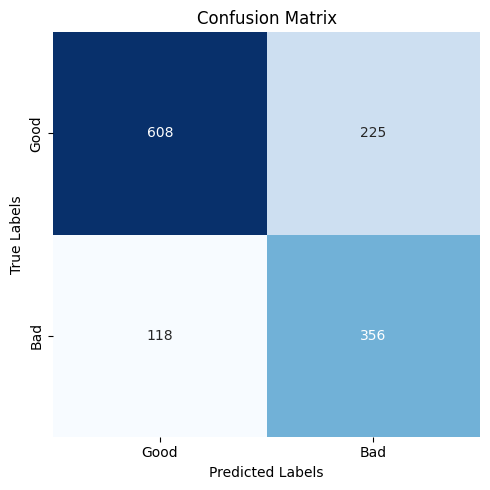

In [7]:
import numpy as np
# cm = np.array([[693, 56], [27, 177]])
cm = np.array([[608, 225], [118, 356]])

# plot_confusion_matrix(cm, ['Good', 'Bad'], 'Dec data collection confusion matrix for XGB')
# plot_confusion_matrix(cm, ['Good', 'Bad'], 'Test Data confusion matrix for XGB')
# plot_confusion_matrix(cm, ['Good', 'Bad'], 'Sardine Test data Confusion Matrix' )
plot_confusion_matrix(cm, ['Good', 'Bad'])

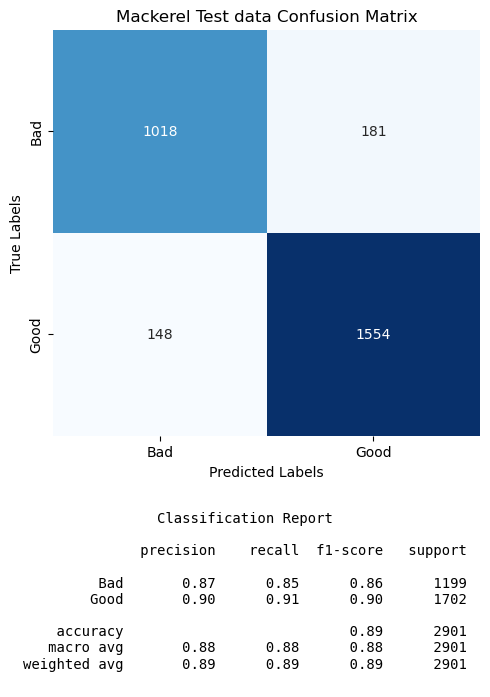

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Sample values for TP, TN, FP, FN
# TP, TN, FP, FN = 1547, 1372, 390, 215

TP, TN, FP, FN = 1554, 1018, 181, 148
# Generate confusion matrix
cm = np.array([[TN, FP], [FN, TP]])
labels = ["Bad", "Good"]

# Generate classification report
y_true = [0] * TN + [0] * FP + [1] * FN + [1] * TP  # Actual labels
y_pred = [0] * TN + [1] * FP + [0] * FN + [1] * TP  # Predicted labels
report = classification_report(y_true, y_pred, target_names=labels)

# Create the figure
fig, ax = plt.subplots(figsize=(5, 5))  # Single subplot to save space

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cbar=False, cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_title("Mackerel Test data Confusion Matrix")

# Add classification report below the heatmap
report_text = f"Classification Report\n\n{report}"
plt.figtext(0.5, -0.375, report_text, wrap=True, horizontalalignment='center', 
            fontsize=10, family='monospace')

plt.tight_layout()
plt.show()

# Save the image in PNG format
fig.savefig("confusion_matrix_report_sardine.png", dpi=300, bbox_inches="tight")


	tp: 21, fn: 67, fp: 3, tn: 28

              precision    recall  f1-score   support

        Good       0.88      0.24      0.37        88
         Bad       0.29      0.90      0.44        31

    accuracy                           0.41       119
   macro avg       0.58      0.57      0.41       119
weighted avg       0.72      0.41      0.39       119



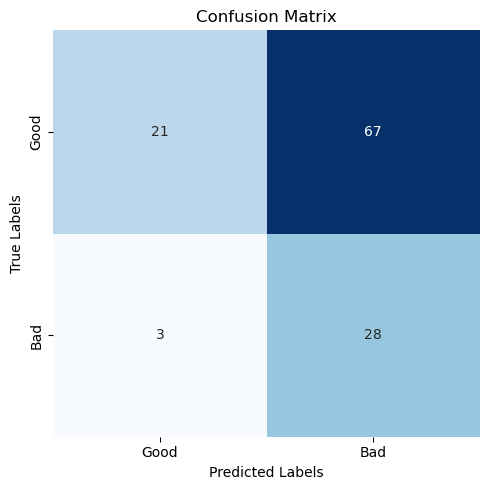

In [45]:
# plot confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(cm, new_class_labels, title='Confusion Matrix'):
    labels = new_class_labels    
    num_labels = len(labels)
    fig_size = max(5, num_labels)  # Ensure a minimum size of 5x5
    print_classification_report_v1(cm)
    plt.figure(figsize=(fig_size, fig_size))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,\
              xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, ['Good', 'Bad'])

In [ ]:
import os

os.environ['AWS_ACCESS_KEY_ID'] = '' 
os.environ['AWS_SECRET_ACCESS_KEY'] = ''

In [40]:
from urllib.parse import urlparse

def download_object_from_s3(url, destination_folder,
                            bucket_name='fish-data-collection'):
    # Parse the URL to extract bucket name and object key
    parsed_url = urlparse(url)
    object_key = parsed_url.path[1:]  # Remove the leading '/'
    new_object_key = object_key.replace(':', '_') # for windows os
    filename = os.path.join(destination_folder, os.path.basename(new_object_key))
    # print(f'Parsed URL: {parsed_url}\nBucket name: {bucket_name}\nObject key: {object_key}\nFilename: {filename}\n')

    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)
    if os.path.exists(filename):
        return

    # Initialize a Boto3 S3 client
    s3 = boto3.client('s3')

    # Download the object
    try:
        response = s3.download_file(Bucket = bucket_name,
                                    Key = object_key,
                                    Filename = filename)
        # print('Object downloaded successfully.')
    except Exception as e:
        print('Error:', str(e))


In [41]:
destination_folder = r"C:\Users\sowmy\Downloads\New app testing data\Sardine"
# destination_folder = r"C:\Users\sowmy\Downloads\New app testing data\White prawns"
bucket_name = 'mobile-api-results-v2'

In [42]:
def download_images_to_folder(df, destination_folder,
                              bucket_name = 'mobile-api-results-v2'):
    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)
    d = {'G': 'Good', 'B': 'Bad'}
    for index, row in tqdm(df.iterrows()):
        input_url = row[1]
        output_url = row[2]
        species = row[-3]
        date = row[-4]
        try:
            label = d[row[3]]
        except:
            continue
        input_folder = os.path.join(destination_folder, 'input', date, species, label)
        # output_folder = os.path.join(destination_folder, 'output', date, species)

        # print(f'\nDownloading images from {input_url} and {output_url} to {input_folder} and {output_folder}')
        # print(f'\nDownloading images from {input_url} to {input_folder}')
        # break
        
        # Download input image
        download_object_from_s3(input_url, input_folder, bucket_name)
        # break
        # Download output image
        # download_object_from_s3(output_url, output_folder, bucket_name)

    # print('Images downloaded successfully.')


# Example usage:
# df is your DataFrame containing input and output URLs in columns 1 and 2
# destination_folder is the folder where you want to save the images
# download_images_to_folder(df, destination_folder)
# download_images_to_folder(result_df, destination_folder)

To download app testing images for a species between a date range

In [ ]:
# date_range = ['2023-11-23', '2024-06-10']
# all_dates = sorted(df.Date.unique())
# date_list = [date for date in all_dates if date_range[0] <= date <= date_range[1]]

dates = ['2024-11-26', '2024-11-21', '2024-11-19', '2024-11-14', '2024-11-12', 
         '2024-11-07', '2024-10-29', '2024-10-24', '2024-10-22', '2024-08-13', 
         '2024-08-12', '2024-07-30', '2024-07-16', '2024-07-11', '2024-06-11', 
         '2024-06-04', '2024-05-28', '2024-05-23', '2024-04-05']
date_list = dates

for date in date_list:
    filters = {'Species': ['sardine'], 'Date': [date]}
    result_df = filter_df(df, filters)
    if result_df.empty: continue
    download_images_to_folder(result_df, destination_folder)
    print(f'Downloaded images for {date}\n')
    

16it [00:17,  1.11s/it]


Downloaded images for 2024-11-26



48it [00:53,  1.11s/it]


Downloaded images for 2024-11-21



61it [01:07,  1.11s/it]


...

Downloaded images for 2024-05-28



30it [00:32,  1.09s/it]


Downloaded images for 2024-05-23



36it [00:39,  1.10s/it]

Downloaded images for 2024-04-05



In [46]:
import os, shutil
src = r"C:\Users\sowmy\Downloads\New app testing data\Sardine\input"
des = r"C:\Users\sowmy\Downloads\New app testing data\Sardine\input\scale_data"
os.makedirs(des, exist_ok=True)

for date in os.listdir(src):
    if date=='scale_data': continue
    f = os.path.join(src, date, 'sardine')
    for folder in os.listdir(f):
        folder_path = os.path.join(f, folder)
        new_folder = os.path.join(des, folder)
        os.makedirs(new_folder, exist_ok=True)
        for file in os.listdir(folder_path):
            src_file = os.path.join(folder_path, file)
            new_file = os.path.join(new_folder, file)
            shutil.copy(src_file, new_file)

To combine all the input date folders' data into one common folder

In [ ]:
# ### combined app testing data
# src_folder = r"C:\Users\sowmy\Downloads\New app testing data\Sardine\input"
# des_folder = r"C:\Users\sowmy\Downloads\New app testing data\Sardine\input_combined"

# from tqdm import tqdm
# import os
# import shutil

# for date in os.listdir(src_folder):
#     datefolder = os.path.join(src_folder, date)
#     for species in tqdm(os.listdir(datefolder), 
#                         desc=f'{date} {species} processing'):
#         speciesfolder = os.path.join(datefolder, species)
#         new_species_folder = os.path.join(des_folder, species)
#         os.makedirs(new_species_folder, exist_ok=True)
#         for label in os.listdir(speciesfolder):
#             labelfolder = os.path.join(speciesfolder, label)
#             new_label_folder = os.path.join(new_species_folder, label)
#             os.makedirs(new_label_folder, exist_ok=True)
#             for file in os.listdir(labelfolder):
#                 src_file = os.path.join(labelfolder, file)
#                 des_file = os.path.join(new_label_folder, file)
#                 if os.path.exists(des_file): continue
#                 shutil.copy(src_file, des_file)

# print('Images downloaded successfully.')

In [39]:
import psycopg2
import pandas as pd
conn = psycopg2.connect(
    dbname="fishdata",
    user="fishdata",
    password="Jalkirani",
    # host="fishdatacollection.cegw5dvtv2xs.ap-south-1.rds.amazonaws.com",
    host="fishdata-collection.c5gmcqq8k94k.ap-south-1.rds.amazonaws.com",
    port="5432"
)
cur = conn.cursor()
cur.execute("SELECT * FROM fishinfo")
rows = cur.fetchall()
column_names = [desc[0] for desc in cur.description]
df = pd.DataFrame(rows, columns=column_names)
cur.close()
conn.close()
df.head()

,id,type,labels,description,image_url
0,77,tuna,good,None,https://fish-data-collection.s3.ap-south-1.ama...
1,79,tuna,bad,shreyas demo,https://fish-data-collection.s3.ap-south-1.ama...
2,80,rohu,good,None,https://fish-data-collection.s3.ap-south-1.ama...
3,81,mackerel,ok,None,https://fish-data-collection.s3.ap-south-1.ama...
4,82,mackerel,good,None,https://fish-data-collection.s3.ap-south-1.ama...


In [40]:
df.tail()

,id,type,labels,description,image_url
81676,89938,pink perch,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....
81677,89939,pink perch,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....
81678,89940,pink perch,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....
81679,89941,pink perch,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....
81680,89942,pink perch,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....


In [41]:
df.shape

(81681, 5)

In [42]:
df.dtypes

id              int64
type           object
labels         object
description    object
image_url      object
dtype: object

In [43]:
# Drop rows with missing values in 'description' column
df.dropna(subset=['description'], inplace=True)

In [44]:
df.shape

(23940, 5)

In [45]:
df['type'].unique()

array(['tuna                ', 'mackerel            ',
       'katla               ', 'rohu                ',
       'indian salmon       ', 'trial_purpose       ',
       'trail_purpose       ', 'trial               ',
       'white prawns        ', 'sardine             ',
       'test                ', 'pink perch          ',
       'roopchand           ', 'tilapia             ',
       'tiger prawns        ', 'barracuda           ',
       'travely             ', 'white pomfret       ',
       'seer                ', 'red prawns          ',
       'croaker             ', 'sea prawns          ',
       'lady                ', 'c boss              ',
       'mullet              ', 'blue crab           ',
       'hilisa              ', 'dotted crab         '], dtype=object)

In [46]:
import re

# Function to remove extra spaces for string columns
def remove_extra_spaces(column):
    if column.dtype == 'object':
        return column.apply(lambda x: re.sub(r'\s+', ' ', x).strip())
    return column

# Apply the function to all columns except the first column
df.iloc[:, 1:] = df.iloc[:, 1:].apply(remove_extra_spaces)


In [47]:
df['type'].unique()

array(['tuna', 'mackerel', 'katla', 'rohu', 'indian salmon',
       'trial_purpose', 'trail_purpose', 'trial', 'white prawns',
       'sardine', 'test', 'pink perch', 'roopchand', 'tilapia',
       'tiger prawns', 'barracuda', 'travely', 'white pomfret', 'seer',
       'red prawns', 'croaker', 'sea prawns', 'lady', 'c boss', 'mullet',
       'blue crab', 'hilisa', 'dotted crab'], dtype=object)

In [48]:
df['labels'].unique()

array(['bad', 'good', 'ok'], dtype=object)

In [49]:
df['description'].unique()

array(['shreyas demo', '5 fish', 'katla', 'katala', 'basa',
       'trial_purpose', 'demo', 'bekar taste hai', 'Softness', 'Test',
       'a', 'à', '', 'i9o ypoppuppp0p0uuuuup', 'l', 'w', 'Tuna Fish',
       'Good', 'Red Head in Prawns', 'o', 'up',
       'Softness, Cuts and Damage', 'Softness, Red Head in Prawns',
       'Cuts and Damage', 'Size', 'hi', 'tr', 'Cuts and Damage, Softness',
       'Smell', 'Red Head in Prawns, Softness', 'Others, Softness',
       'Softness, Smell', 'Color, Smell', 'Size, Red Head in Prawns',
       'Red Head in Prawns, Cuts and Damage',
       'Cuts and Damage, Red Head in Prawns', 'Smell, Softness',
       'Softness, Color', 'Softness, Red Head in Prawns, Smell',
       'Softness, Size', 'Softness, Cuts and Damage, Smell', 'Color',
       'Softness, Color, Red Head in Prawns',
       'Cuts and Damage, Softness, Red Head in Prawns', 'Color, Softness',
       'Size, Softness', 'Smell, Color, Softness',
       'Softness, Cuts and Damage, Size',
       'Cu

In [50]:
# Filter the DataFrame to keep rows where 'description' doesn't contain any of the strings
filter_strings = ['demo', 'test', 'trial_purpose', 'trial', 'trail_purpose']
c1 = df['type'].str.contains('|'.join(filter_strings))

# Filter the DataFrame to keep rows where 'labels' doesn't contain 'ok  '
c2 = df['labels']=='ok'

# Filter the DataFrame to keep rows where 'description' doesn't contain any of the strings
filter_strings = ['shreyas demo', '5 fish', 'Demo', 'katla', 'katala', 'basa',
              'trial_purpose', 'demo', 'bekar taste hai', 'Test', 'a', 'à', '',
              'i9o ypoppuppp0p0uuuuup', 'l', 'w', 'Tuna Fish', 'Good', 'o', 'up',
              'hi', 'tr', ]
c3 = df['description'].apply(lambda x: any(item==x for item in filter_strings))

df = df[(~c1)&(~c2)&(~c3)]

In [51]:
df

,id,type,labels,description,image_url
3616,80310,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....
3626,81921,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....
3627,82094,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....
3631,82785,white prawns,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....
3633,83128,white prawns,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....
...,...,...,...,...,...
81676,89938,pink perch,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....
81677,89939,pink perch,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....
81678,89940,pink perch,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....
81679,89941,pink perch,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....


In [52]:
df['type'].value_counts()

white prawns     9609
mackerel         7150
sardine          6286
tuna              250
sea prawns        193
seer               69
pink perch         67
tiger prawns       49
white pomfret      37
indian salmon      24
red prawns         24
dotted crab        20
barracuda          14
lady               12
mullet             10
blue crab           8
c boss              7
tilapia             6
croaker             5
hilisa              1
Name: type, dtype: int64

In [53]:
df['image_url'].iloc[0]

'https://fish-data-collection-v2.s3.ap-south-1.amazonaws.com/mackerel/bad/20240910100835143_mackerel_bad.jpeg'

In [56]:
df.to_csv(r"D:\QzenseLabs\testing_dataset2.csv", index=False)

In [57]:
import pandas as pd
import os

In [60]:
feedback_df = pd.read_csv(r"D:\QzenseLabs\testing_dataset2.csv")
feedback_df['Filename'] = feedback_df['image_url'].apply(lambda x: os.path.basename(x))
feedback_df['Date'] = feedback_df['Filename'].apply(lambda x: os.path.splitext(x)[0].split('_')[0])
feedback_df['Date'] = feedback_df['Date'].apply(lambda x: f'{x[0:4]}-{x[4:6]}-{x[6:8]}')
# feedback_df.drop(['image_url'], axis=1, inplace=True)

In [61]:
feedback_df

,id,type,labels,description,image_url,Filename,Date
0,80310,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240910100835143_mackerel_bad.jpeg,2024-09-10
1,81921,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240926094227777_mackerel_bad.jpeg,2024-09-26
2,82094,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20241002102426458_mackerel_bad.jpeg,2024-10-02
3,82785,white prawns,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20241015103307962_white prawns_bad.jpeg,2024-10-15
4,83128,white prawns,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20241017101814512_white prawns_bad.jpeg,2024-10-17
...,...,...,...,...,...,...,...
23836,89938,pink perch,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20250128113440816_pink perch_bad.jpeg,2025-01-28
23837,89939,pink perch,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20250128113451297_pink perch_bad.jpeg,2025-01-28
23838,89940,pink perch,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20250128113459764_pink perch_bad.jpeg,2025-01-28
23839,89941,pink perch,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20250128113508768_pink perch_bad.jpeg,2025-01-28


In [61]:
feedback_df['type'].unique()

array(['mackerel', 'white prawns', 'tiger prawns', 'white pomfret',
       'pink perch', 'sardine', 'seer', 'red prawns', 'croaker', 'tuna',
       'indian salmon', 'barracuda', 'sea prawns', 'lady', 'c boss',
       'mullet', 'blue crab', 'hilisa', 'tilapia'], dtype=object)

In [62]:
feedback_df['description'].unique()

array(['Softness', 'Red Head in Prawns', 'Softness, Cuts and Damage',
       'Softness, Red Head in Prawns', 'Cuts and Damage', 'Size',
       'Cuts and Damage, Softness', 'Smell',
       'Red Head in Prawns, Softness', 'Others, Softness',
       'Softness, Smell', 'Color, Smell', 'Size, Red Head in Prawns',
       'Red Head in Prawns, Cuts and Damage',
       'Cuts and Damage, Red Head in Prawns', 'Smell, Softness',
       'Softness, Color', 'Softness, Red Head in Prawns, Smell',
       'Softness, Size', 'Softness, Cuts and Damage, Smell', 'Color',
       'Softness, Color, Red Head in Prawns',
       'Cuts and Damage, Softness, Red Head in Prawns', 'Color, Softness',
       'Size, Softness', 'Smell, Color, Softness',
       'Softness, Cuts and Damage, Size',
       'Cuts and Damage, Size, Softness',
       'Softness, Cuts and Damage, Color', 'Red Head in Prawns, Size',
       'Softness, Size, Red Head in Prawns',
       'Softness, Cuts and Damage, Red Head in Prawns',
       'Cuts and

In [63]:
filtered_df = feedback_df[feedback_df['labels']=='bad']
filtered_df = filtered_df[filtered_df['description'].str.contains('Cuts')]

In [64]:
filtered_df = filtered_df[filtered_df['type']=='sardine']

In [65]:
filtered_df

,id,type,labels,description,image_url,Filename,Date
561,23594,sardine,bad,Cuts and Damage,https://fish-data-collection.s3.ap-south-1.ama...,20230916114452264_sardine_bad.jpeg,2023-09-16
562,23596,sardine,bad,Cuts and Damage,https://fish-data-collection.s3.ap-south-1.ama...,20230916114514979_sardine_bad.jpeg,2023-09-16
563,23601,sardine,bad,Cuts and Damage,https://fish-data-collection.s3.ap-south-1.ama...,20230916114612276_sardine_bad.jpeg,2023-09-16
643,23863,sardine,bad,Cuts and Damage,https://fish-data-collection.s3.ap-south-1.ama...,20230919123618572_sardine_bad.jpeg,2023-09-19
645,23865,sardine,bad,"Softness, Cuts and Damage",https://fish-data-collection.s3.ap-south-1.ama...,20230919123637784_sardine_bad.jpeg,2023-09-19
...,...,...,...,...,...,...,...
23079,85950,sardine,bad,"Softness, Cuts and Damage",https://fish-data-collection-v2.s3.ap-south-1....,20241203102411837_sardine_bad.jpeg,2024-12-03
23528,88356,sardine,bad,"Cuts and Damage, Softness",https://fish-data-collection-v2.s3.ap-south-1....,20250107115016759_sardine_bad.jpeg,2025-01-07
23533,88395,sardine,bad,"Softness, Cuts and Damage",https://fish-data-collection-v2.s3.ap-south-1....,20250107120121687_sardine_bad.jpeg,2025-01-07
23534,88399,sardine,bad,"Softness, Cuts and Damage",https://fish-data-collection-v2.s3.ap-south-1....,20250107120310894_sardine_bad.jpeg,2025-01-07


In [63]:
filtered_df[(filtered_df['Date']>'2024-04-30')&(filtered_df['description'].str.lower().str.contains('size'))]

,id,type,labels,description,Filename,Date
10760,65863,sardine,bad,Size,20240525103614445_sardine_bad.jpeg,2024-05-25
18114,63008,sardine,bad,Size,20240502100653822_sardine_bad.jpeg,2024-05-02
18143,63037,sardine,bad,"Size, Softness",20240502101213407_sardine_bad.jpeg,2024-05-02
18160,63054,sardine,bad,"Size, Softness",20240502101604319_sardine_bad.jpeg,2024-05-02
19444,64464,sardine,bad,Size,20240514093027591_sardine_bad.jpeg,2024-05-14
19515,64534,sardine,bad,"Size, Softness",20240514094832469_sardine_bad.jpeg,2024-05-14
19561,64580,sardine,bad,"Cuts and Damage, Size, Softness",20240514095818001_sardine_bad.jpeg,2024-05-14
19944,65014,sardine,bad,"Softness, Size",20240516101021501_sardine_bad.jpeg,2024-05-16
19945,65015,sardine,bad,Size,20240516101030217_sardine_bad.jpeg,2024-05-16
19946,65016,sardine,bad,Size,20240516101040274_sardine_bad.jpeg,2024-05-16


In [64]:
filtered_df = feedback_df[feedback_df['description'].str.contains('Softness')]
filtered_df = filtered_df[filtered_df['labels']=='bad']
filtered_df = filtered_df[filtered_df['type']=='sardine']

In [65]:
filtered_df

,id,type,labels,description,Filename,Date
334,23090,sardine,bad,Softness,20230915094934980_sardine_bad.jpeg,2023-09-15
336,23091,sardine,bad,Softness,20230915094945234_sardine_bad.jpeg,2023-09-15
337,23092,sardine,bad,Softness,20230915094957671_sardine_bad.jpeg,2023-09-15
338,23093,sardine,bad,Softness,20230915095009089_sardine_bad.jpeg,2023-09-15
339,23094,sardine,bad,Softness,20230915095019471_sardine_bad.jpeg,2023-09-15
...,...,...,...,...,...,...
22219,70299,sardine,bad,Softness,20240820132110081_sardine_bad.jpeg,2024-08-20
22220,70300,sardine,bad,Softness,20240820132122632_sardine_bad.jpeg,2024-08-20
22221,70301,sardine,bad,Softness,20240820132124485_sardine_bad.jpeg,2024-08-20
22222,70302,sardine,bad,Softness,20240820132135641_sardine_bad.jpeg,2024-08-20


In [66]:
filtered_df[(filtered_df['Date']>'2024-04-30')&(filtered_df['description']=='Softness')]

,id,type,labels,description,Filename,Date
10749,65837,sardine,bad,Softness,20240525102859293_sardine_bad.jpeg,2024-05-25
10750,65842,sardine,bad,Softness,20240525103024674_sardine_bad.jpeg,2024-05-25
10751,65844,sardine,bad,Softness,20240525103059972_sardine_bad.jpeg,2024-05-25
10752,65846,sardine,bad,Softness,20240525103116442_sardine_bad.jpeg,2024-05-25
10753,65848,sardine,bad,Softness,20240525103156975_sardine_bad.jpeg,2024-05-25
...,...,...,...,...,...,...
22219,70299,sardine,bad,Softness,20240820132110081_sardine_bad.jpeg,2024-08-20
22220,70300,sardine,bad,Softness,20240820132122632_sardine_bad.jpeg,2024-08-20
22221,70301,sardine,bad,Softness,20240820132124485_sardine_bad.jpeg,2024-08-20
22222,70302,sardine,bad,Softness,20240820132135641_sardine_bad.jpeg,2024-08-20


In [91]:
ndf = filtered_df[(filtered_df['Date']>'2024-04-30')&(filtered_df['description']=='Softness')]
import shutil
import os
from tqdm import tqdm

# def copy_files2(src_folder, des_folder, ndf):
#     for filename in ndf['Filename'].values:
#         if filename in os.listdir(des_folder): continue
#         new_dest = os.path.join(des_folder, ndf[ndf['Filename']==filename]['description'].values[0])
#         if not os.path.exists(new_dest):
#             os.makedirs(new_dest)
#         shutil.copy(os.path.join(src_folder, filename), new_dest)

def copy_files(src_folder, des_folder, ndf):
    for filename in os.listdir(src_folder):
        if filename in ndf['Filename'].values:
            if filename in os.listdir(des_folder): continue
            shutil.copy(os.path.join(src_folder, filename), des_folder)
        
s3_daily_data_folder = r"C:\Users\sowmy\Downloads\QzenseLabs\qZense Dataset\S3 Daily Data"
des_folder = r"C:\Users\sowmy\Downloads\sardine softness data\sardine\Bad\Softness"

for date in tqdm(os.listdir(s3_daily_data_folder)):
    folder_path = os.path.join(s3_daily_data_folder, date, 'Sardine', 'Bad', 'Single')
    if not os.path.exists(folder_path): continue
    copy_files(folder_path, des_folder, ndf)

100%|██████████| 146/146 [00:32<00:00,  4.46it/s] 


In [90]:
ndf

,Unnamed: 0,id,type,labels,description,image_url,Filename,Date
10737,52488,65837,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20240525102859293_sardine_bad.jpeg,2024-05-25
10738,52489,65842,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20240525103024674_sardine_bad.jpeg,2024-05-25
10739,52490,65844,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20240525103059972_sardine_bad.jpeg,2024-05-25
10740,52491,65846,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20240525103116442_sardine_bad.jpeg,2024-05-25
10741,52492,65848,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20240525103156975_sardine_bad.jpeg,2024-05-25
...,...,...,...,...,...,...,...,...
20963,66673,66750,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20240604112101180_sardine_bad.jpeg,2024-06-04
20964,66674,66751,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20240604112114425_sardine_bad.jpeg,2024-06-04
20965,66675,66752,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20240604112123636_sardine_bad.jpeg,2024-06-04
20966,66676,66753,sardine,bad,Softness,https://fish-data-collection.s3.ap-south-1.ama...,20240604112228342_sardine_bad.jpeg,2024-06-04


In [ ]:
! pip install boto3

In [ ]:
import boto3
import os

os.environ['AWS_ACCESS_KEY_ID'] = ''
os.environ['AWS_SECRET_ACCESS_KEY'] = ''

In [ ]:
from urllib.parse import urlparse

def download_object_from_s3(url, destination_folder,
                            bucket_name='fish-data-collection'):
    # Parse the URL to extract bucket name and object key
    parsed_url = urlparse(url)
    object_key = parsed_url.path[1:]  # Remove the leading '/'
    filename = os.path.join(destination_folder, os.path.basename(object_key))
    # print(f'Parsed URL: {parsed_url}\nBucket name: {bucket_name}\nObject key: {object_key}\n')

    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)
    if os.path.exists(filename):
        return

    # Initialize a Boto3 S3 client
    s3 = boto3.client('s3')

    # Download the object
    try:
        response = s3.download_file(Bucket = bucket_name,
                                    Key = object_key,
                                    Filename = filename)
        # print('Object downloaded successfully.')
    except Exception as e:
        print('Error:', str(e))


In [ ]:
def classify_and_move_images2(df, destination_folder):
    for _, row in df.iterrows():
        image_url = row['image_url']
        image_type = row['type']
        image_label = row['labels']
        image_description = row['description']

        # Create destination directories if they don't exist
        type_folder = os.path.join(destination_folder, image_type)
        labels_folder = os.path.join(type_folder, image_label)
        description_folder = os.path.join(labels_folder, image_description)

        os.makedirs(description_folder, exist_ok=True)

        # Download the image from the provided URL
        download_object_from_s3(image_url, description_folder)

In [ ]:
def classify_and_move_images(df, destination_folder):
    # Group by 'type', 'labels', 'description'
    grouped = df.groupby(['type', 'labels', 'description'])

    # Get the total number of groups for the progress bar
    total_groups = len(grouped)

    from tqdm import tqdm
    for group, group_df in tqdm(grouped, total=total_groups, desc='Processing groups'):
        image_type, image_label, image_description = group
        # Create destination directories based on the grouping
        type_folder = os.path.join(destination_folder, image_type)
        labels_folder = os.path.join(type_folder, image_label)
        description_folder = os.path.join(labels_folder, image_description)

        os.makedirs(description_folder, exist_ok=True)

        desc=f'Moving {image_type}/{image_label}/{image_description} images'
        # Iterate through the group and move images to the appropriate directory
        for _, row in tqdm(group_df.iterrows(), desc=desc):
            image_url = row['image_url']
            image_filename = os.path.basename(image_url)
            new_image_path = os.path.join(description_folder, image_filename)
            # print(f'Moving {image_url} to {new_image_path}')
            # Download the image from the provided URL
            download_object_from_s3(image_url, description_folder)

In [ ]:
destination_folder = r"C:\Users\sowmy\Downloads\sardine softness data"
# classify_and_move_images2(df, destination_folder)
classify_and_move_images2(filtered_df.loc[16629:], destination_folder)

In [ ]:
new_df = df[['type', 'labels', 'description']]

In [ ]:
new_df

,type,labels,description
21448,white prawns,bad,Softness
21452,white prawns,good,Softness
21453,white prawns,bad,Softness
21454,white prawns,bad,Softness
21455,white prawns,bad,Softness
...,...,...,...
23808,sardine,bad,Softness
23809,sardine,bad,"Cuts and Damage, Softness"
23810,sardine,bad,Softness
23811,sardine,bad,"Cuts and Damage, Softness"


In [ ]:
# Create a new DataFrame with unique descriptions for each combination of type and labels
description_df = new_df.groupby(['type', 'labels'])['description'].apply(lambda x: list(set(x))).reset_index()
description_df

,type,labels,description
0,mackerel,bad,"[Cuts and Damage, Softness]"
1,mackerel,good,[Softness]
2,pink perch,bad,[Softness]
3,red prawns,bad,"[Cuts and Damage, Softness, Cuts and Damage, S..."
4,sardine,bad,"[Cuts and Damage, Softness, Cuts and Damage, S..."
5,seer,bad,[Softness]
6,seer,good,[Softness]
7,tiger prawns,bad,[Softness]
8,white pomfret,bad,[Softness]
9,white prawns,bad,"[Cuts and Damage, Softness, Red Head in Prawns..."


In [ ]:
description_df

,type,labels,description
0,mackerel,bad,"[Cuts and Damage, Softness]"
1,mackerel,good,[Softness]
2,pink perch,bad,[Softness]
3,red prawns,bad,"[Cuts and Damage, Softness, Cuts and Damage, S..."
4,sardine,bad,"[Cuts and Damage, Softness, Cuts and Damage, S..."
5,seer,bad,[Softness]
6,seer,good,[Softness]
7,tiger prawns,bad,[Softness]
8,white pomfret,bad,[Softness]
9,white prawns,bad,"[Cuts and Damage, Softness, Red Head in Prawns..."


In [ ]:
description_df['description'][6]

['Softness']

In [ ]:
# Define the function
def process_description(description):
    l = []
    for i in description:
        nl = []
        nl.append(i)
        l.append(tuple(nl))
    return l

In [ ]:
process_description(description_df['description'][6])

[('Softness',)]

In [ ]:
# Apply the function to the 'description' column and store the result in a new column 'processed_description'
description_df['processed_description'] = description_df['description'].apply(process_description)
description_df

,type,labels,description,processed_description
0,mackerel,bad,"[Cuts and Damage, Softness]","[(Cuts and Damage,), (Softness,)]"
1,mackerel,good,[Softness],"[(Softness,)]"
2,pink perch,bad,[Softness],"[(Softness,)]"
3,red prawns,bad,"[Cuts and Damage, Softness, Cuts and Damage, S...","[(Cuts and Damage,), (Softness, Cuts and Damag..."
4,sardine,bad,"[Cuts and Damage, Softness, Cuts and Damage, S...","[(Cuts and Damage, Softness,), (Cuts and Damag..."
5,seer,bad,[Softness],"[(Softness,)]"
6,seer,good,[Softness],"[(Softness,)]"
7,tiger prawns,bad,[Softness],"[(Softness,)]"
8,white pomfret,bad,[Softness],"[(Softness,)]"
9,white prawns,bad,"[Cuts and Damage, Softness, Red Head in Prawns...","[(Cuts and Damage, Softness,), (Red Head in Pr..."


In [ ]:
des_dir = '/kaggle/working/app_testing_segmented_dataset'
os.makedirs(des_dir, exist_ok=True)

In [ ]:
for date in os.listdir(des_dir):
    folder_path = os.path.join(des_dir, date)
    os.makedirs(folder_path, exist_ok=True)
    for species in tqdm(os.listdir(folder_path), desc=date):
        species_folder = os.path.join(folder_path, species)
        os.makedirs(species_folder, exist_ok=True)
        for label in os.listdir(species_folder):
            label_folder = os.path.join(species_folder, label)
            os.makedirs(label_folder, exist_ok=True)
            for img in os.listdir(label_folder):
                img_path = os.path.join(label_folder, img)
                seg_img_list = segment_img(img_path, seg_model)
                if seg_img_list is None: continue
                for i, seg_img in enumerate(seg_img_list):
                    seg_img = cv2.cvtColor(seg_img, cv2.COLOR_RGB2BGR)
                    img_name = img_path.split('/')[-1]
                    img_name = img_name.split('.')[0]+f'_({i})'+'.jpg'
                    filepath = os.path.join(label_folder, img_name)
                    if os.path.exists(filepath): continue
                    cv2.imwrite(filepath, seg_img)

In [ ]:
import os

# Replace 'YOUR_USERNAME' and 'YOUR_API_KEY' with your actual values
os.environ['KAGGLE_USERNAME'] = 'sowmyamaddala'
os.environ['KAGGLE_KEY'] = '0c6517e7a88df3fa24e7ca0ef96d0501'

# Extract API key from downloaded kaggle.json (not recommended for notebooks)
# with open('/path/to/your/kaggle.json') as f:
#     key = f.read()
# os.environ['KAGGLE_KEY'] = key

In [ ]:
import kaggle

In [ ]:
! kaggle datasets init -p "/kaggle/working/"

In [ ]:
# read the json file
import json
with open('/kaggle/working/dataset-metadata.json') as f:
    metadata = json.load(f)
    
metadata 

In [ ]:
# modify the json
metadata['id'] = 'sowmyamaddala/sardine-segmented-dataset'
metadata['title'] = 'Sardine Segmented Dataset'
metadata['licenses'] = [{'name': 'CC0-1.0'}]

# write the json
with open('/kaggle/working/dataset-metadata.json', 'w') as f:
    json.dump(metadata, f)

In [ ]:
with open('/kaggle/working/dataset-metadata.json') as f:
    metadata = json.load(f)
    
metadata 

In [ ]:
! kaggle datasets create -p "/kaggle/working/" -r tar